In [1]:
import os
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image
from collections import Counter  

In [4]:
csv="train.csv"
image="colored_images"

In [5]:
df=pd.read_csv(csv)
print(df.head)
print(df.shape)
print(df.columns)


<bound method NDFrame.head of            id_code  diagnosis
0     000c1434d8d7          2
1     001639a390f0          4
2     0024cdab0c1e          1
3     002c21358ce6          0
4     005b95c28852          0
...            ...        ...
3657  ffa47f6a7bf4          2
3658  ffc04fed30e6          0
3659  ffcf7b45f213          2
3660  ffd97f8cd5aa          0
3661  ffec9a18a3ce          2

[3662 rows x 2 columns]>
(3662, 2)
Index(['id_code', 'diagnosis'], dtype='object')


In [6]:
print(df["diagnosis"].value_counts().sort_index())   #checking the labels 

diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [10]:
#assinging the classes

class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

df["class_name"] = df["diagnosis"].map(class_names)

print(df["class_name"].value_counts())

class_name
No DR               1805
Moderate             999
Mild                 370
Proliferative DR     295
Severe               193
Name: count, dtype: int64


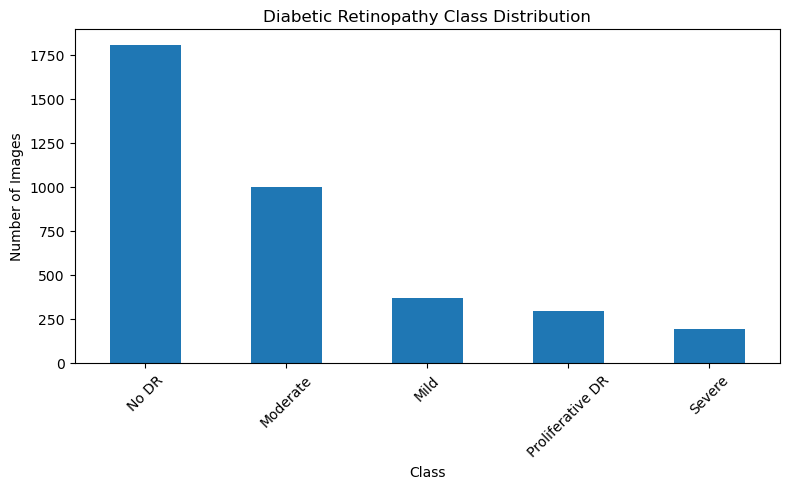

In [11]:
# demonstrates the class imbalance

class_counts = df["class_name"].value_counts()

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")

plt.title("Diabetic Retinopathy Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
#verifying that the actual images agree with the csv file

for folder in os.listdir(image):
    folder_path =os.path.join(image,folder)

    if os.path.isdir(folder_path):
        files=os.listdir(folder_path)
        print(folder,":",len(files))

Mild : 370
Moderate : 999
No_DR : 1805
Proliferate_DR : 295
Severe : 193


In [14]:
#Checking whether every CSV image exists

extensions = [".png", ".jpg", ".jpeg"]

image_paths = []

for image_id in df["id_code"]:
    found_path = None

    for ext in extensions:
        path = os.path.join(image, ext)
        
    # Search inside class folders
    for class_folder in os.listdir(image):
        folder_path = os.path.join(image, class_folder)

        if not os.path.isdir(folder_path):
            continue

        for ext in extensions:
            possible_path = os.path.join(
                folder_path,
                image_id + ext
            )

            if os.path.exists(possible_path):
                found_path = possible_path
                break

        if found_path:
            break

    image_paths.append(found_path)

df["image_path"] = image_paths

In [15]:
missing = df["image_path"].isna().sum()

print("Missing images:", missing)

Missing images: 0


In [23]:
#Verify CSV label vs folder label

folder_to_label = {
    "No_DR": 0,
    "Mild": 1,
    "Moderate": 2,
    "Severe": 3,
    "Proliferate_DR": 4
}

In [24]:
df["folder_label"] = df["folder"].map(folder_to_label)

mismatches = df[df["diagnosis"] != df["folder_label"]]

print("Label mismatches:", len(mismatches))

Label mismatches: 0


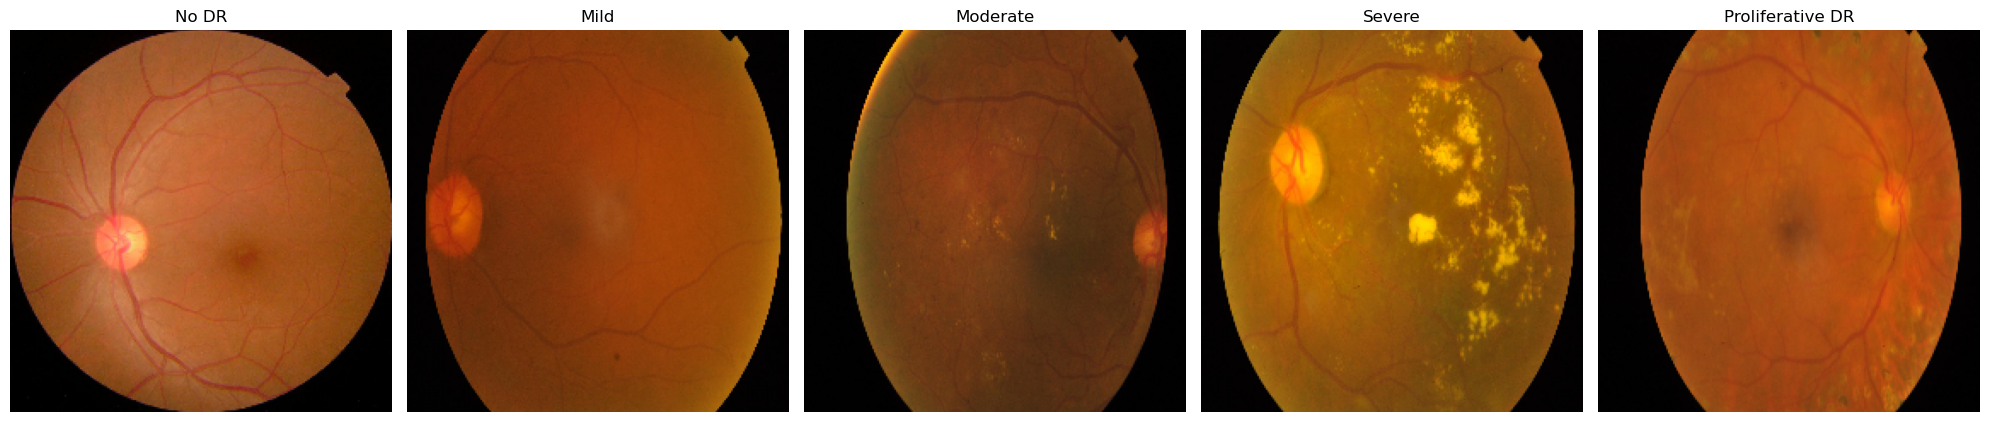

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for label in range(5):

    sample = df[df["diagnosis"] == label].iloc[0]

    image = Image.open(sample["image_path"])

    axes[label].imshow(image)
    axes[label].set_title(class_names[label])
    axes[label].axis("off")

plt.tight_layout()
plt.show()

In [26]:
#Checking image dimensions
sizes = []

for path in df["image_path"].dropna():

    with Image.open(path) as img:
        sizes.append(img.size)

size_counts = Counter(sizes)

print("Number of different image sizes:", len(size_counts))
print("Most common sizes:")

for size, count in size_counts.most_common(10):
    print(size, ":", count)

Number of different image sizes: 1
Most common sizes:
(224, 224) : 3662


In [27]:
#Checking for corrupted images
corrupted = []

for path in df["image_path"].dropna():

    try:
        with Image.open(path) as img:
            img.verify()

    except Exception:
        corrupted.append(path)

print("Corrupted images:", len(corrupted))

Corrupted images: 0
